In [1]:
!git clone -b transfer-learning https://github.com/KaustubhMukdam/Pneumonia-Detection.git /kaggle/working/Pneumonia-Detection

Cloning into '/kaggle/working/Pneumonia-Detection'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 77 (delta 21), reused 57 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 975.70 KiB | 5.58 MiB/s, done.
Resolving deltas: 100% (21/21), done.


# Import Libraries and Constants

In [2]:
import os

os.environ["PYTHONHASHSEED"] = "42"

import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_FRACTION = 0.15
EPOCHS = 20
MINIMUM_SENSITIVITY = 0.95

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Dataset Configuration

In [3]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/"
    "chest_xray/chest_xray"
)

TRAIN_DIR = DATASET_ROOT / "train"

LABEL_TO_ID = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
}

VALID_EXTENSIONS = {".jpeg", ".jpg"}

assert TRAIN_DIR.exists(), f"Missing directory: {TRAIN_DIR}"

# Training manifest

In [4]:
def build_manifest(split_dir: Path) -> pd.DataFrame:
    records = []

    for class_name, label in LABEL_TO_ID.items():
        class_dir = split_dir / class_name

        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in VALID_EXTENSIONS:
                records.append({
                    "path": str(image_path),
                    "label": label,
                    "class_name": class_name,
                })

    return pd.DataFrame(records)


train_full_df = build_manifest(TRAIN_DIR)

print("Raw training images:", len(train_full_df))
print("\nClass counts:")
print(train_full_df["class_name"].value_counts())

Raw training images: 5216

Class counts:
class_name
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64


# Stratified Validation Split (Duplicate-safe)

In [5]:
def file_sha256(file_path: str) -> str:
    digest = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


train_full_df["sha256"] = train_full_df["path"].apply(file_sha256)

assert train_full_df.groupby("sha256")["label"].nunique().max() == 1

hash_groups_df = (
    train_full_df.groupby("sha256", as_index=False)
    .agg(
        label=("label", "first"),
        file_count=("path", "size"),
    )
)

train_hashes, val_hashes = train_test_split(
    hash_groups_df["sha256"],
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    stratify=hash_groups_df["label"],
)

train_df = (
    train_full_df[train_full_df["sha256"].isin(train_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

val_df = (
    train_full_df[train_full_df["sha256"].isin(val_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

assert set(train_df["path"]).isdisjoint(set(val_df["path"]))

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining class counts:")
print(train_df["class_name"].value_counts())

print("\nValidation class counts:")
print(val_df["class_name"].value_counts())

Training images: 4432
Validation images: 784

Training class counts:
class_name
PNEUMONIA    3292
NORMAL       1140
Name: count, dtype: int64

Validation class counts:
class_name
PNEUMONIA    583
NORMAL       201
Name: count, dtype: int64


# Tensorflow Dataset Pipeline
here we would be using almost the same pipeline as we didi for baseline, but the difference would be here we wount be dividing it by 255

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe: pd.DataFrame, training: bool=False):
    paths = dataframe["path"].to_numpy(dtype=str)
    labels = dataframe["label"].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)

I0000 00:00:1786300256.434827      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786300256.437866      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Sanity check

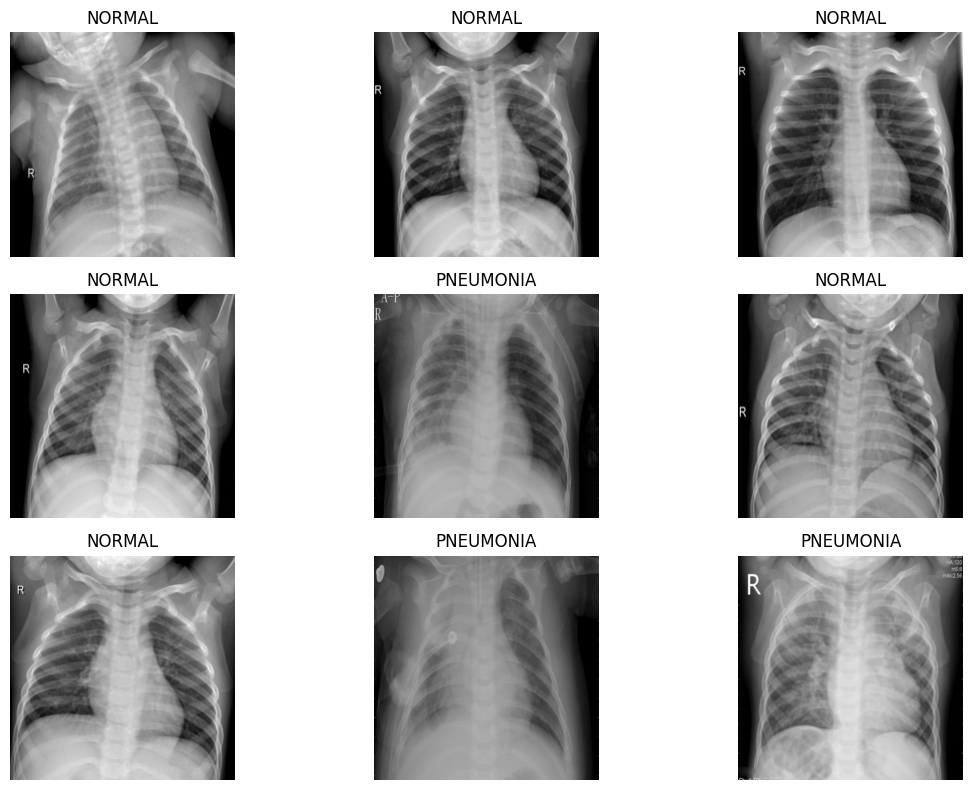

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)
    plt.imshow(images[index].numpy().astype("uint8"))

    class_name = (
        "PNEUMONIA"
        if labels[index].numpy() == 1
        else "NORMAL"
    )

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conservative augmentation

In [8]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=7/360,
            fill_mode="reflect",
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect",
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="reflect",
        ),
    ],
    name="augmentation",
)

# Build Frozen EfficientNetB0

In [11]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg",
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="chest_xray",
)

x = augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="pneumonia_probability",
)(x)

efficientnet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientb0_frozen",
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4,
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
    ],
)

efficientnet_model.summary()

Model: "efficientb0_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chest_xray (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Callbacks

In [12]:
CHECKPOINT_PATH = (
    "/kaggle/working/efficientnetb0_frozen_best.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

# Train Frozen EfficientNetB0

In [13]:
history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


E0000 00:00:1786300501.423763      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientb0_frozen_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7528 - loss: 0.5271 - precision: 0.7625 - recall: 0.9694 - roc_auc: 0.6774
Epoch 1: val_loss improved from None to 0.31326, saving model to /kaggle/working/efficientnetb0_frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetb0_frozen_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 253ms/step - accuracy: 0.7838 - loss: 0.4618 - precision: 0.7890 - recall: 0.9678 - roc_auc: 0.8026 - val_accuracy: 0.8916 - val_loss: 0.3133 - val_precision: 0.8866 - val_recall: 0.9794 - val_roc_auc: 0.9595
Epoch 2/20
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8549 - loss: 0.3398 - precision: 0.8560 - recall: 0.9695 - roc_auc: 0.9221
Epoch 2: val_loss improved from 0.31326 to 0.24993, saving model to /kaggle/working/efficientnetb0_frozen_best.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetb0_frozen_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.8671 - loss: 0.3170 - prec

# Training Curve

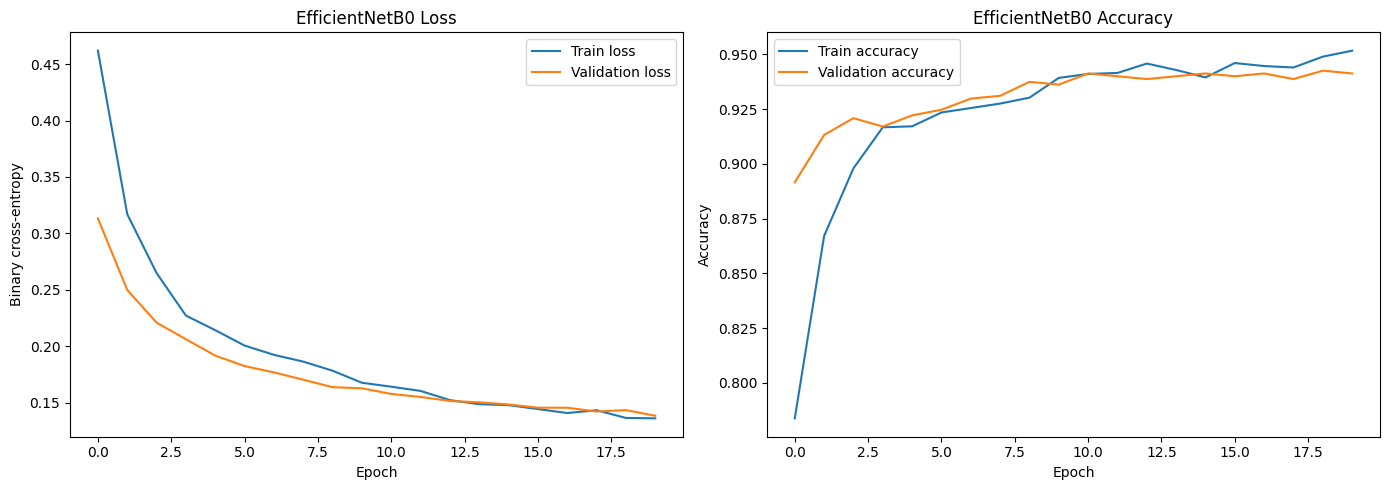

In [14]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_df["loss"],
    label="Train loss",
)

axes[0].plot(
    history_df["val_loss"],
    label="Validation loss",
)

axes[0].set_title("EfficientNetB0 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].plot(
    history_df["accuracy"],
    label="Train accuracy",
)

axes[1].plot(
    history_df["val_accuracy"],
    label="Validation accuracy",
)

axes[1].set_title("EfficientNetB0 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


# Best validation checkpoint

In [17]:
best_efficient_model = tf.keras.models.load_model(
    CHECKPOINT_PATH,
)
best_efficient_model

<Functional name=efficientb0_frozen, built=True>

# Validation metrics at threshold 0.50

In [18]:
validation_probabilities = (
    best_efficient_model.predict(val_ds, verbose=1).ravel()
)

validation_labels = val_df["label"].to_numpy()

default_predictions = (
    validation_probabilities >= 0.50
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    validation_labels,
    default_predictions,
    labels=[0, 1],
).ravel()

default_validation_results = {
    "threshold" : 0.50,
    "accuracy" : accuracy_score(
        validation_labels,
        default_predictions,
    ),
    "precision" : precision_score(
        validation_labels,
        default_predictions,
        zero_division=0,
    ),
    "specificity" : tn / (tn + fp),
    "f1_score" : f1_score(
        validation_labels,
        default_predictions,
        zero_division=0,
    ),
    "roc_auc" : roc_auc_score(
        validation_labels,
        validation_probabilities,
    ),
    "true_negatives" : tn,
    "false_positivies" : fp,
    "false_negatives" : fn,
    "true_positives" : tp,
}

pd.Series(default_validation_results).round(4)

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step


threshold             0.5000
accuracy              0.9413
precision             0.9621
specificity           0.8905
f1_score              0.9605
roc_auc               0.9853
true_negatives      179.0000
false_positivies     22.0000
false_negatives      24.0000
true_positives      559.0000
dtype: float64

# Validation threshold analysis

In [20]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation_labels,
        predictions,
        labels=[0,1],
    ).ravel()

    threshold_rows.append(
        {
            "threshold" : round(float(threshold), 2),
            "sensitivity" : recall_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "specitivity" : tn / (tn + fp),
            "precision" : precision_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "false_negatives" : fn,
            "false_positivies" : fp,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)

eligible_thresholds = threshold_results[
    threshold_results["sensitivity"] >= MINIMUM_SENSITIVITY
]

selected_threshold_row = (
    eligible_thresholds
    .sort_values("threshold", ascending=False)
    .iloc[0]
)

selected_threshold_row

threshold            0.570000
sensitivity          0.950257
specitivity          0.915423
precision            0.970228
false_negatives     29.000000
false_positivies    17.000000
Name: 47, dtype: float64

# Validation confusion matrix at selected threshold

Selected validation threshold: 0.57
              precision    recall  f1-score   support

      NORMAL     0.8638    0.9154    0.8889       201
   PNEUMONIA     0.9702    0.9503    0.9601       583

    accuracy                         0.9413       784
   macro avg     0.9170    0.9328    0.9245       784
weighted avg     0.9430    0.9413    0.9419       784



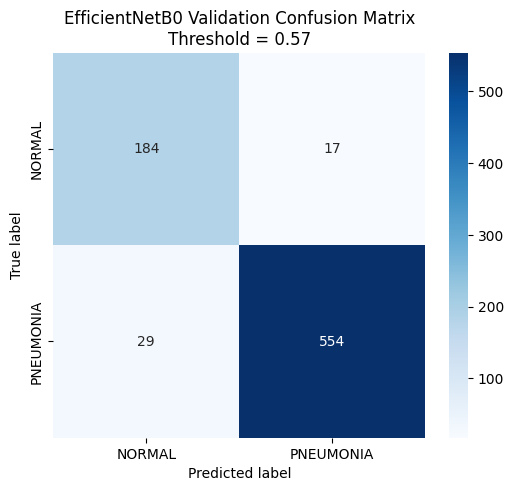

In [23]:
SELECTED_THRESHOLD = selected_threshold_row["threshold"]

selected_predictions = (
    validation_probabilities >= SELECTED_THRESHOLD
).astype(int)

print(
    f"Selected validation threshold: {SELECTED_THRESHOLD:.2f}"
)

print(
    classification_report(
        validation_labels,
        selected_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4,
        zero_division=0,
    )
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(
        validation_labels,
        selected_predictions,
    ),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)

plt.title(
    f"EfficientNetB0 Validation Confusion Matrix\n"
    f"Threshold = {SELECTED_THRESHOLD:.2f}"
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Validation ROC-curve

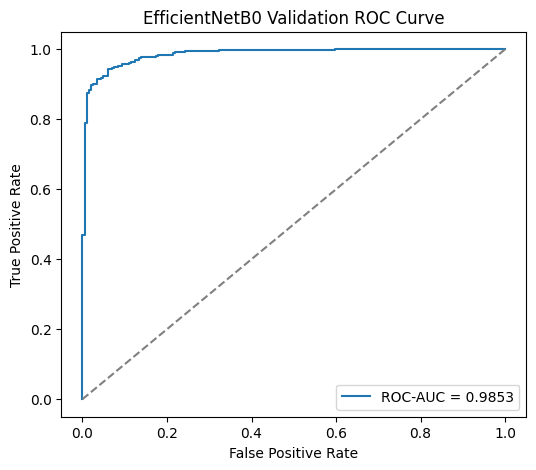

In [25]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    validation_labels,
    validation_probabilities,
)

validation_roc_auc = roc_auc_score(
    validation_labels,
    validation_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {validation_roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
)

plt.title("EfficientNetB0 Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [26]:
history_df.to_csv(
    "/kaggle/working/efficientnetb0_history.csv",
    index=False,
)

threshold_results.to_csv(
    "/kaggle/working/efficientnetb0_threshold_analysis.csv",
    index=False,
)

pd.DataFrame(
    [default_validation_results]
).to_csv(
    "/kaggle/working/efficientnetb0_validation_metrics.csv",
    index=False,
)